In [2]:
# Pipeline
# Pipeline prevents data leakage by ensuring transformations are 
# fitted only on training data and then applied to test data without refitting.

## Using pipeline model drives out weights, mean and other parameter
# using train data and when we use feed test data to predict 
## only those learned weights and mean and other parameter are used by test data
# to learn the pattern and predict

# During .fit(X_train, y_train)
# 1. StandardScaler → FITS on X_train (learns mean, std)
# 2. StandardScaler → TRANSFORMS X_train

# 3. PolynomialFeatures → FITS (just defines structure)
# 4. PolynomialFeatures → TRANSFORMS X_train

# 5. LinearRegression → FITS on transformed data

In [ ]:
# Block 2
## Train model with Pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing  import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from sklearn.model_selection import train_test_split
 
df = pd.read_csv("house_price_v6_final.csv")
X = df.drop('target',axis = 1)
y = df['target']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
df.head()
model = Pipeline([("SS",StandardScaler()),
                  ("Poly_fea",PolynomialFeatures(degree=2)),
                  ("LR",LinearRegression())])

model.fit(X_train,y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

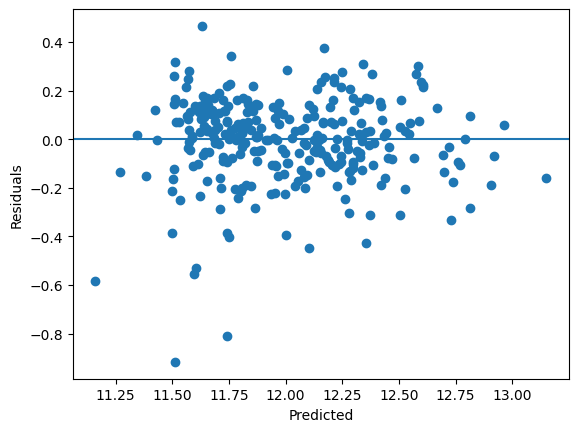

In [4]:
# Block 4
residuals = y_test - y_pred

import matplotlib.pyplot as plt

plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

In [5]:
# Good model
# plot show no pattern left all  captured by the model\
# Residual plot having patter 
# model is too simple - underfitting  - curved pattern
# Error increases with value of predicted -  funnel shape
## Cluster - missing imortant features
## Check large errors
import numpy as np
errors = np.abs(residuals)
print(errors)
large_error_indices = np.argsort(errors)[-5:]
print(X_test.iloc[large_error_indices])
print(y_test.iloc[large_error_indices])
print(y.head())

497     0.150321
1261    0.037906
411     0.161994
1046    0.448986
1033    0.164502
          ...   
477     0.070749
674     0.096335
1407    0.193131
649     0.038209
720     0.113721
Name: target, Length: 292, dtype: float64
      quality_area  garagecars  area_per_room  renovation_age  house_age
1428          3872           1     161.333333               0         80
462           4320           1     144.000000              44         44
532            334           0     111.333333              57         61
810           5220           2     208.800000              58         58
30            5268           1     188.142857              58         88
1428    11.074436
462     11.041064
532     10.579005
810     10.933000
30      10.596660
Name: target, dtype: float64
0    12.247699
1    12.109016
2    12.317171
3    11.849405
4    12.429220
Name: target, dtype: float64


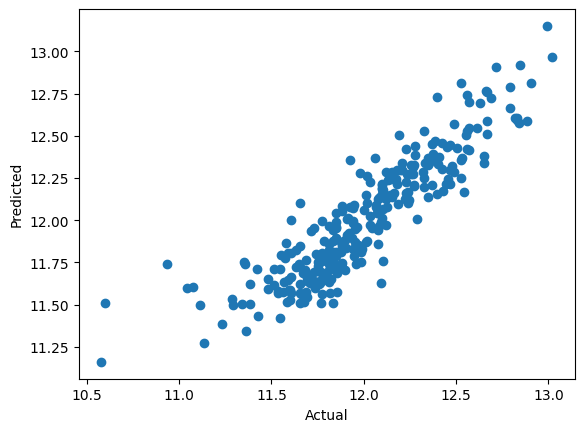

In [6]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [7]:
# | Pattern      | Problem         | Fix            |
# | ------------ | --------------- | -------------- |
# | Curve        | Underfitting    | Add polynomial |
# | Large spread | High variance   | Regularization |
# | Outliers     | Bad data        | Clean data     |
# | Clusters     | Missing feature | Add feature    |

Residuals should be randomly scattered around zero because all systematic patterns should be captured by the model. Any pattern in residuals indicates the model is missing structure in the data.

A curved pattern in residuals indicates the model is too simple (often linear) and fails to capture non-linear relationships in the data.

Large errors highlight data points where the model performs poorly, helping identify outliers, missing features, or regions where the model is weak.

In [8]:
## Block 5
## Feature Improvement
# Create , improve or remove feature to improve model performance
# | Observation       | Action                      |
# | ----------------- | --------------------------- |
# | Curved residuals  | Add polynomial features     |
# | Missing pattern   | Create interaction features |
# | Outliers          | Clean or cap values         |
# | High error region | Add new feature             |

# Types of Feature Improvement
# 1. Add Polynomial Features  - capture non  linearity
# 2. Interaction Features
# Combine features:
# 3. Transform Features
# Handle skew:
# log(x)
# sqrt(x)
# Remove Irrelevant Features
# 👉 If feature adds noise:
# Handle Outliers
# Example:
# Cap extreme values or remove them

In [9]:
## Adding one feature Area**2 and analysing the errors
# Add feature
X_train['area_sq'] = X_train['area_per_room'] ** 2
X_test['area_sq'] = X_test['area_per_room'] ** 2
print(X_train)
print(X_test)
# Train
model = LinearRegression()
model.fit(X_train, y_train)
# Evaluate
y_pred_one = model.predict(X_test)
mse_one = mean_squared_error(y_test,y_pred_one)
r2_one = r2_score(y_test,y_pred_one)
print("mse_more_fetaure",mse_one)
print("r2_one",r2_one)
print("mse",mse)
print("r2",r2)

      quality_area  garagecars  area_per_room  renovation_age  house_age  \
254           6570           1     219.000000              53         53   
1063         15820           2     282.500000              13         14   
636           6935           1     173.375000              55         55   
1289         11860           1     197.666667              44        117   
514           3945           1     131.500000              57         81   
...            ...         ...            ...             ...        ...   
1095          8704           2     181.333333              21         21   
1130         13260           1     245.555556              57        127   
1294          6432           2     178.666667               0          1   
860           6582           2     156.714286              25         26   
1126         13713           2     217.666667               2          3   

           area_sq  
254   47961.000000  
1063  79806.250000  
636   30058.890625  
128

In [10]:
## Validate with cross validation
from sklearn.model_selection import cross_val_score
CV_one = cross_val_score(model,X,y,cv=5)
print(CV_one)
print(CV_one.mean())

# With R2 score
score1 = cross_val_score(model,X,y,cv=5,scoring="r2")
print(score1)

## For MSE
scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
mse = -scores.mean()
print("MSE:", mse)

## Steps
# Train multiple models  
# → Cross-validate  
# → Compare average R²  
# → Pick best  
# → Final test evaluation

# after choosing the best model then do model.fit(X_train,y_train)

[0.81414891 0.83182962 0.8198998  0.80888724 0.79904227]
0.8147615665916177
[0.81414891 0.83182962 0.8198998  0.80888724 0.79904227]
MSE: 0.028849819661901043


In [11]:
## Block 6
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2)),
    ("linreg", LinearRegression())
])
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Final MSE:", mse)
print("Final R2:", r2)

## Save Module
import joblib
joblib.dump(final_model, "model.pkl")

Final MSE: 0.030803821487440493
Final R2: 0.8049631553883947


['model.pkl']

In [12]:
df.columns

Index(['quality_area', 'garagecars', 'area_per_room', 'renovation_age',
       'house_age', 'target'],
      dtype='object')

Hour 8
Documentation

1. Problem Statement
Predict target variable (House Price) using given feature.

2. Data Description
Dataset was preprocessed and final features are quality_area,garagecars,area_per_room, renovation_age,house_age.

3. Approach
- Cleaned the data
- Split into Train/Test
- Used Pipeline (Scaling + Polynomial + Regression)

4. Model Tried
- Linear Regression
- Polynomial (degree 2)
- Linear Regression with one more extra feature created using the existing feature.

5. Evalaution Metrics
- MSE
- R2

6. Results 
- Polynomial with original feature performed the best.
- R2 ~ 0.8
- MSE Improved compared to baseline

7. Error Analysis
- Residuals were mostly random
- Some learge errors identified

8. Final Model
Selected a polynomial regression with degree 2 pipeline

9. Future improvements
- Try more featues
- Try advanced models
- Hyperparameter Tuning

Write Up
This project focuses on predicting the target variable using regression techniques. The dataset was preprocessed and split into training and testing sets. A pipeline approach was used, incorporating scaling, polynomial feature transformation, and linear regression.

Multiple models were tested, including a baseline linear regression model, manual feature addition, and polynomial regression. Evaluation was done using MSE and R² score.

The polynomial regression model (degree 2) performed best, achieving improved accuracy and better generalization. Residual analysis indicated that the model captured most patterns in the data, with minimal systematic error.

Further improvements can be made by adding more relevant features, applying advanced models, and performing hyperparameter tuning.

In [18]:
## Hour 7
## Problem - longest Subarray with sum k
## Pattern - prefix sum and hashmap
nums = [1, -1, 5, -2, 3]
k = 3  
Output = 4
ar = []
def longestSubarray(nums, k):
    prefix_sum = 0
    hashmap = {}
    max_len = 0

    for i, num in enumerate(nums):
        prefix_sum += num

        if prefix_sum == k:
            max_len = i + 1

        if prefix_sum - k in hashmap:
            max_len = max(max_len, i - hashmap[prefix_sum - k])

        if prefix_sum not in hashmap:
            hashmap[prefix_sum] = i

    return max_len
print(longestSubarray(nums,k))

4
